In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df.head()
df.shape

(19, 2)

Text(0, 0.5, 'Package(in lpa)')

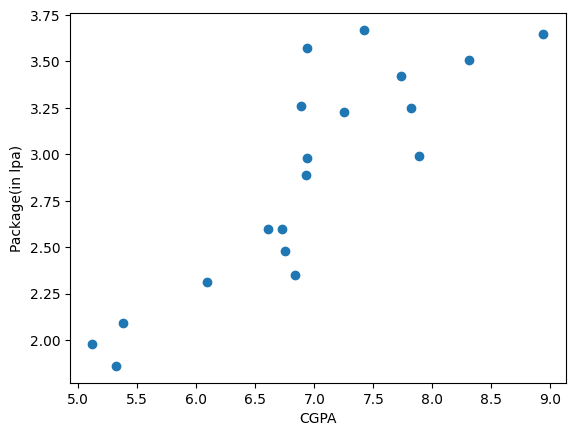

In [5]:
plt.scatter(df['cgpa'],df['package '])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [6]:
X=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [7]:
y

0     3.26
1     1.98
2     3.25
3     3.67
4     3.57
5     2.99
6     2.60
7     2.48
8     2.31
9     3.51
10    1.86
11    2.60
12    3.65
13    2.89
14    3.42
15    3.23
16    2.35
17    2.09
18    2.98
Name: package , dtype: float64

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr=LinearRegression()

In [11]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'Package(in lpa)')

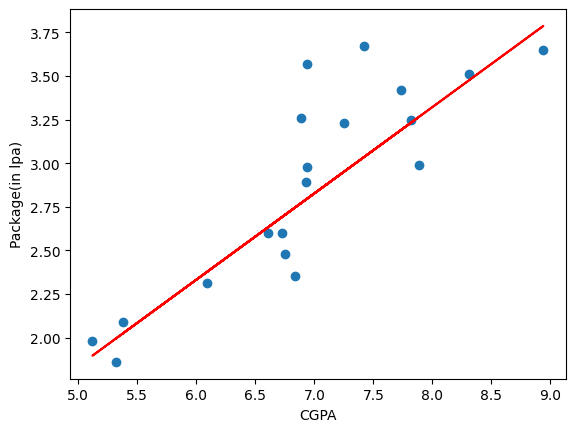

In [12]:
plt.scatter(df['cgpa'],df['package '])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [14]:
y_pred=lr.predict(X_test)

In [15]:
y_test.values

array([3.51, 3.57, 3.42, 3.26])

In [17]:
print('MAE',mean_absolute_error(y_test,y_pred))

MAE 0.38181909001028635


In [18]:
print('MSE',mean_squared_error(y_test,y_pred))

MSE 0.2226001590233928


In [20]:
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.47180521300998024


In [21]:
print("MSE",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

MSE -15.307703957757713


In [22]:
# Adjusted R2 score
X_test.shape

(4, 1)

In [23]:

1 - ((1-r2)*(4-1)/(4-1-1))

-23.46155593663657

In [27]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(19)

new_df1 = new_df1[['cgpa','random_feature','package ']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.150815,3.26
1,5.12,0.801113,1.98
2,7.82,0.342990,3.25
3,7.42,0.655320,3.67
4,6.94,0.740886,3.57


Text(0, 0.5, 'Package(in lpa)')

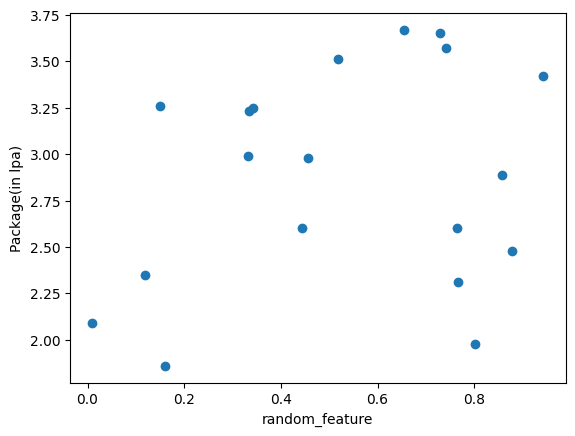

In [29]:
plt.scatter(new_df1['random_feature'],new_df1['package '])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [30]:

X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [32]:
lr = LinearRegression()

In [33]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
y_pred = lr.predict(X_test)

In [35]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score -14.966470000735276


In [37]:
1 - ((1-r2)*(4-1)/(4-1-2))

-46.899410002205826